# Imports and Data Formatting

In [20]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)
import plotly.express as px
import requests
from scipy.stats import rankdata, norm
from statsmodels.stats.multitest import multipletests
import numpy as np
import plotly.graph_objects as go
import sqlite3

In [5]:
db_path = '/s/project/cancer_pred/MASTER/emma/human_genome_old.db'

In [6]:
splicing = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet')
outrider = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet')
protrider = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet')
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'

In [ ]:
SAMPLE_ID = 'random_id'

germline_raw = pd.read_parquet(GERMLINE_DATA_PATH)
somatic_raw = pd.read_parquet(SOMATIC_DATA_PATH)
germline_raw['origin'] = 'germline'
somatic_raw['origin'] = 'somatic'
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()

In [8]:
sample_to_oncotree = outrider[[SAMPLE_ID, 'Oncotree Code']].drop_duplicates().set_index(SAMPLE_ID)['Oncotree Code'].to_dict()
res['Oncotree Code'] = res[SAMPLE_ID].map(sample_to_oncotree)

sample_to_diag = outrider[[SAMPLE_ID, 'Diag']].drop_duplicates().set_index(SAMPLE_ID)['Diag'].to_dict()
res['Diag'] = res[SAMPLE_ID].map(sample_to_diag)

# Plots

In [9]:
url = "http://oncotree.mskcc.org/api/tumorTypes"
response = requests.get(url)
tumor_types = response.json()

mapping_data = []
for tumor in tumor_types:
    mapping_data.append({
        'Oncotree Code': tumor.get('code'),
        'Lineage': tumor.get('tissue')
    })

oncotree_mapping = pd.DataFrame(mapping_data)

cohort_df = res[['random_id', 'Oncotree Code']].drop_duplicates()

cohort_lineage_df = pd.merge(cohort_df, oncotree_mapping, on='Oncotree Code', how='left')

lineage_counts = cohort_lineage_df.groupby(['Lineage', 'Oncotree Code']).size().reset_index(name='Sample Count')

In [10]:
cohort_df = res[['random_id', 'Oncotree Code']].drop_duplicates()
cohort_lineage_df = pd.merge(cohort_df, oncotree_mapping, on='Oncotree Code', how='left')

cohort_lineage_df['Lineage'] = cohort_lineage_df['Lineage'].fillna('Other')

TOP_N_LINEAGES = 12    
MIN_SUBTYPE_SAMPLES = 30 

top_lineages = cohort_lineage_df['Lineage'].value_counts().nlargest(TOP_N_LINEAGES).index
cohort_lineage_df['Clean_Lineage'] = cohort_lineage_df['Lineage'].apply(
    lambda x: x if x in top_lineages else 'Other Lineages'
)

subtype_counts = cohort_lineage_df.groupby(['Clean_Lineage', 'Oncotree Code']).size().reset_index(name='Count')

def bin_small_subtypes(df, min_samples):
    processed = []
    for lineage, group in df.groupby('Clean_Lineage'):
        large = group[group['Count'] >= min_samples].copy()
        small_count = group[group['Count'] < min_samples]['Count'].sum()
        
        if small_count > 0:
            other_row = pd.DataFrame([{
                'Clean_Lineage': lineage,
                'Oncotree Code': f'Other ({lineage})',
                'Count': small_count
            }])
            large = pd.concat([large, other_row], ignore_index=True)
        processed.append(large)
    return pd.concat(processed, ignore_index=True)

clean_counts = bin_small_subtypes(subtype_counts, min_samples=MIN_SUBTYPE_SAMPLES)

fig = px.sunburst(
    clean_counts,
    path=['Clean_Lineage', 'Oncotree Code'],
    values='Count',
    color='Clean_Lineage',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Pan-Cancer Cohort Composition (Major Lineages & Subtypes)'
)

fig.update_traces(
    textinfo="label+value",
    insidetextorientation="radial"
)
fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    font=dict(size=14)
)
fig.show()

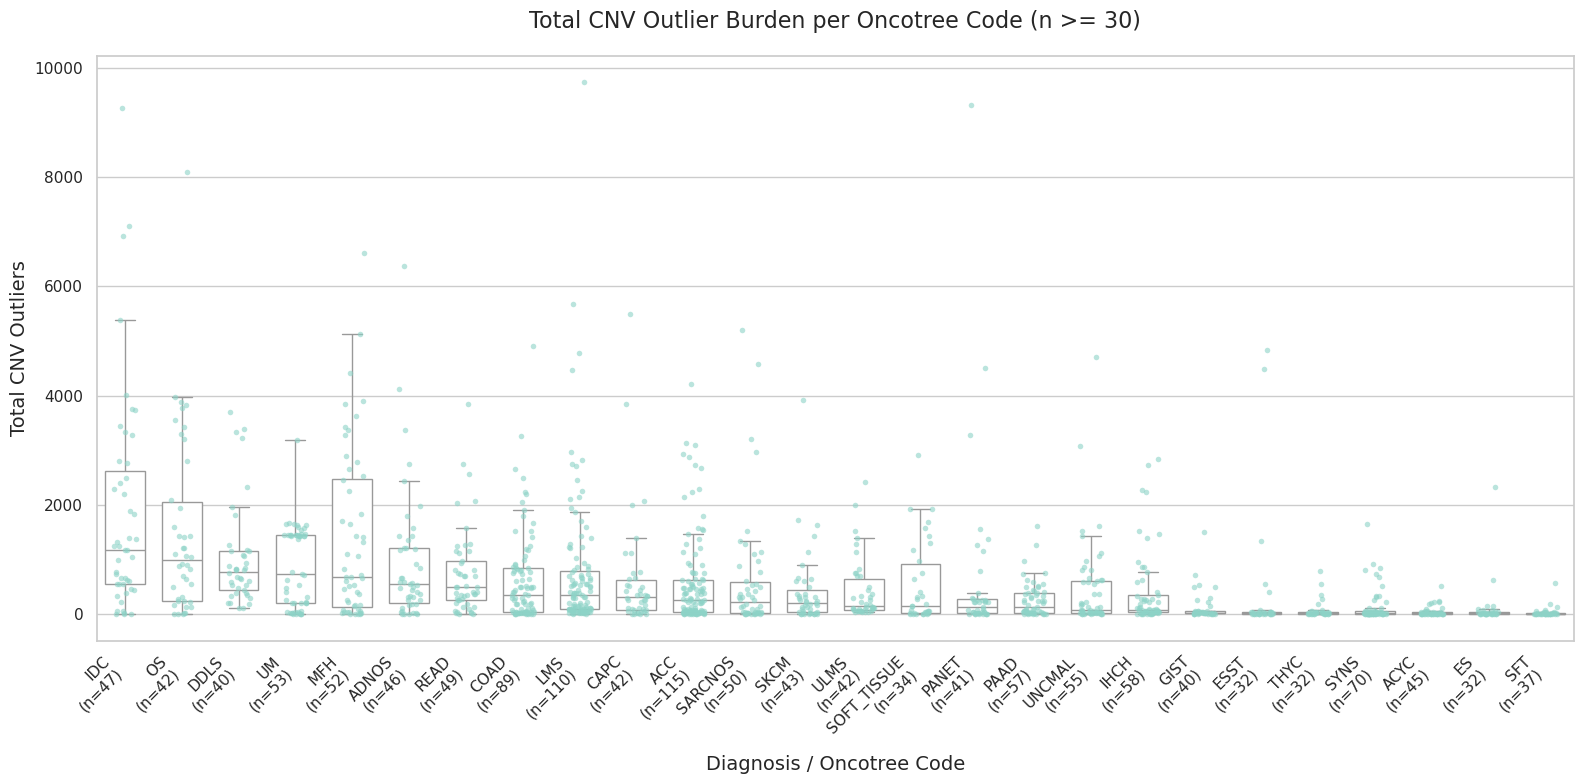

In [11]:
DIAG_COL = 'Oncotree Code'
SAMPLE_ID = 'random_id'
MIN_SAMPLES = 30
truncate_y_axis = False 
y_axis_quantile_limit = 0.95

burden_df = res.groupby(SAMPLE_ID).size().reset_index(name='burden')

patient_mapping = res[[SAMPLE_ID, DIAG_COL]].drop_duplicates()

analysis_df = pd.merge(burden_df, patient_mapping, on=SAMPLE_ID)

diag_counts = analysis_df[DIAG_COL].value_counts()
valid_diags = diag_counts[diag_counts >= MIN_SAMPLES].index.tolist()
plot_df = analysis_df[analysis_df[DIAG_COL].isin(valid_diags)].copy()

median_order = plot_df.groupby(DIAG_COL)['burden'].median().sort_values(ascending=False).index
plot_df[DIAG_COL] = pd.Categorical(plot_df[DIAG_COL], categories=median_order, ordered=True)
plot_df = plot_df.sort_values(DIAG_COL)


plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

if truncate_y_axis:
    y_max = plot_df['burden'].quantile(y_axis_quantile_limit)

sns.boxplot(
    data=plot_df, 
    x=DIAG_COL, 
    y='burden', 
    color='white',
    width=0.7,
    showfliers=False
)

sns.stripplot(
    data=plot_df, 
    x=DIAG_COL, 
    y='burden', 
    color='#8dd3c7',
    jitter=0.2, 
    size=4, 
    alpha=0.6
)

plt.title(f'Total CNV Outlier Burden per {DIAG_COL} (n >= {MIN_SAMPLES})', fontsize=16, pad=20)
plt.ylabel('Total CNV Outliers', fontsize=14)
plt.xlabel('Diagnosis / Oncotree Code', fontsize=14)

tick_labels = [f"{diag}\n(n={diag_counts[diag]})" for diag in median_order]
plt.xticks(ticks=range(len(median_order)), labels=tick_labels, rotation=45, ha='right')

if truncate_y_axis:
    plt.ylim(bottom=-max(1, y_max * 0.05), top=y_max)

plt.tight_layout()
plt.show()

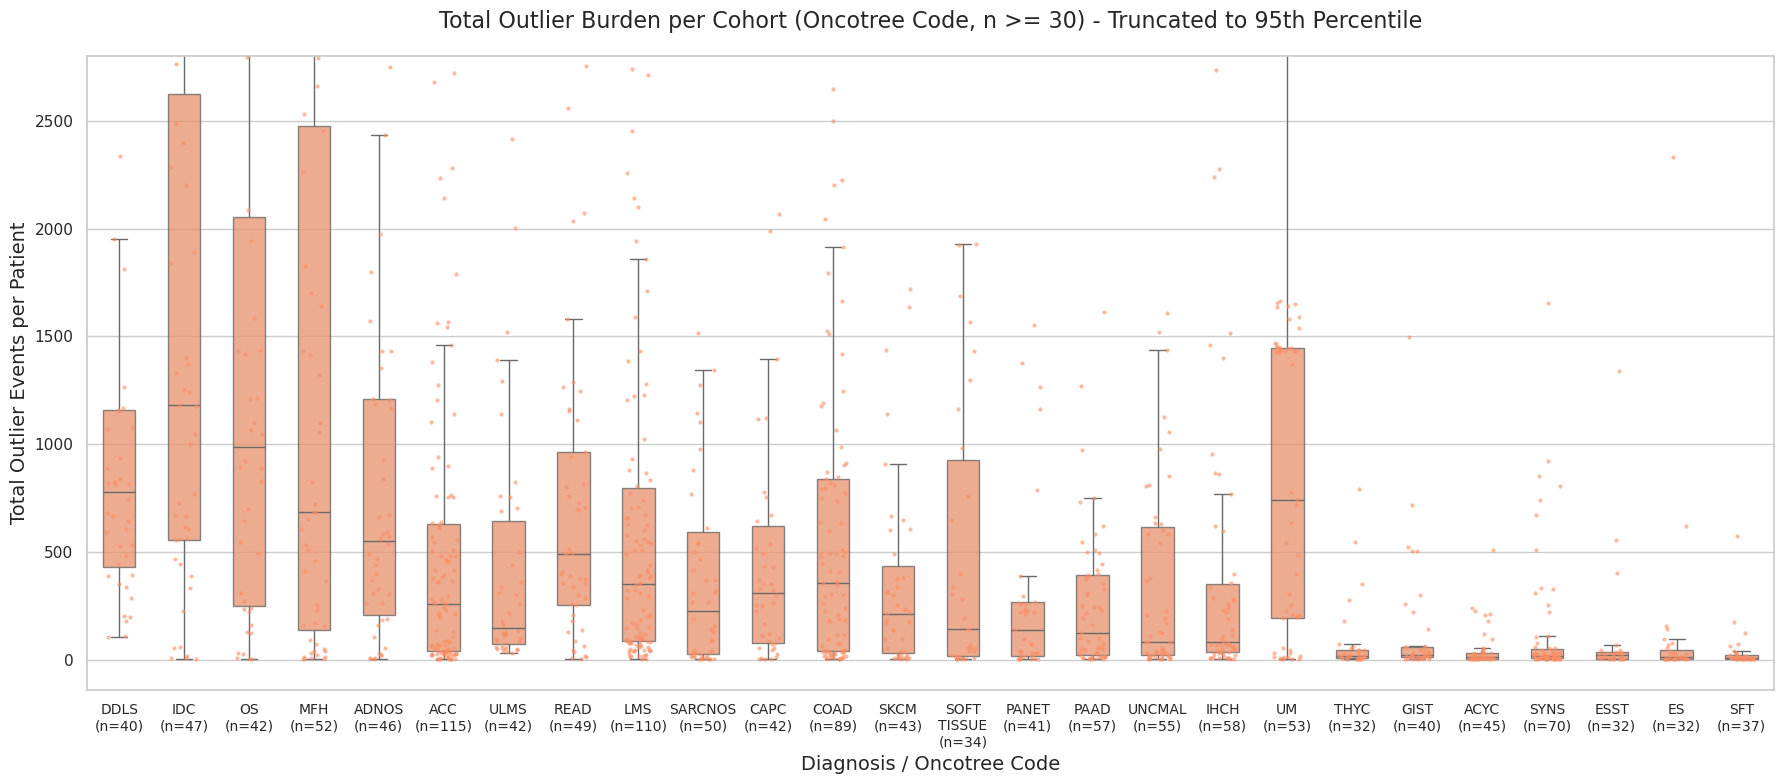

In [12]:
DIAG_COL = 'Oncotree Code'
SAMPLE_ID = 'random_id'
MIN_SAMPLES = 30

unique_segments = res.drop_duplicates(subset=[SAMPLE_ID, 'seqnames', 'start', 'end'])
cnv_burden = unique_segments.groupby(SAMPLE_ID).size().reset_index(name='CNV')
total_burden = res.groupby(SAMPLE_ID).size().reset_index(name='Total Outliers')
splicing_burden = splicing.groupby(SAMPLE_ID).size().reset_index(name='Splicing')

analysis_df = res[[SAMPLE_ID, DIAG_COL]].drop_duplicates().copy()
for df in [cnv_burden, total_burden, splicing_burden]:
    analysis_df = pd.merge(analysis_df, df, on=SAMPLE_ID, how='left')

#analysis_df.fillna(0, inplace=True)

diag_counts = analysis_df[DIAG_COL].value_counts()
valid_diags = diag_counts[diag_counts >= MIN_SAMPLES].index.tolist()
plot_df = analysis_df[analysis_df[DIAG_COL].isin(valid_diags)].copy()

median_order = plot_df.groupby(DIAG_COL)['CNV'].median().sort_values(ascending=False).index
plot_df[DIAG_COL] = pd.Categorical(plot_df[DIAG_COL], categories=median_order, ordered=True)
plot_df = plot_df.sort_values(DIAG_COL)

labels = [f"{diag}\n(n={diag_counts[diag]})" for diag in median_order]
labels[13] = 'SOFT\nTISSUE\n(n=34)'

melt_vars_1 = ['CNV', 'Splicing']
melted_df_1 = plot_df.melt(id_vars=[SAMPLE_ID, DIAG_COL], value_vars=melt_vars_1, var_name='Outlier Type', value_name='Burden')

y_max_2 = plot_df['Total Outliers'].quantile(0.95)

plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")
set2_colors = sns.color_palette("Set2")

sns.boxplot(
    data=plot_df, x=DIAG_COL, y='Total Outliers',
    color=set2_colors[1], width=0.5, showfliers=False, boxprops={'alpha': 0.8}
)
sns.stripplot(
    data=plot_df, x=DIAG_COL, y='Total Outliers',
    color=set2_colors[1], jitter=0.2, size=3, alpha=0.6
)

plt.xticks(ticks=range(len(median_order)), labels=labels, fontsize=10, ha='center')
plt.ylim(bottom=-max(1, y_max_2 * 0.05), top=y_max_2)
plt.title(f'Total Outlier Burden per Cohort ({DIAG_COL}, n >= {MIN_SAMPLES}) - Truncated to 95th Percentile', fontsize=16, pad=20)
plt.ylabel('Total Outlier Events per Patient', fontsize=14)
plt.xlabel('Diagnosis / Oncotree Code', fontsize=14)
plt.tight_layout()
plt.show()

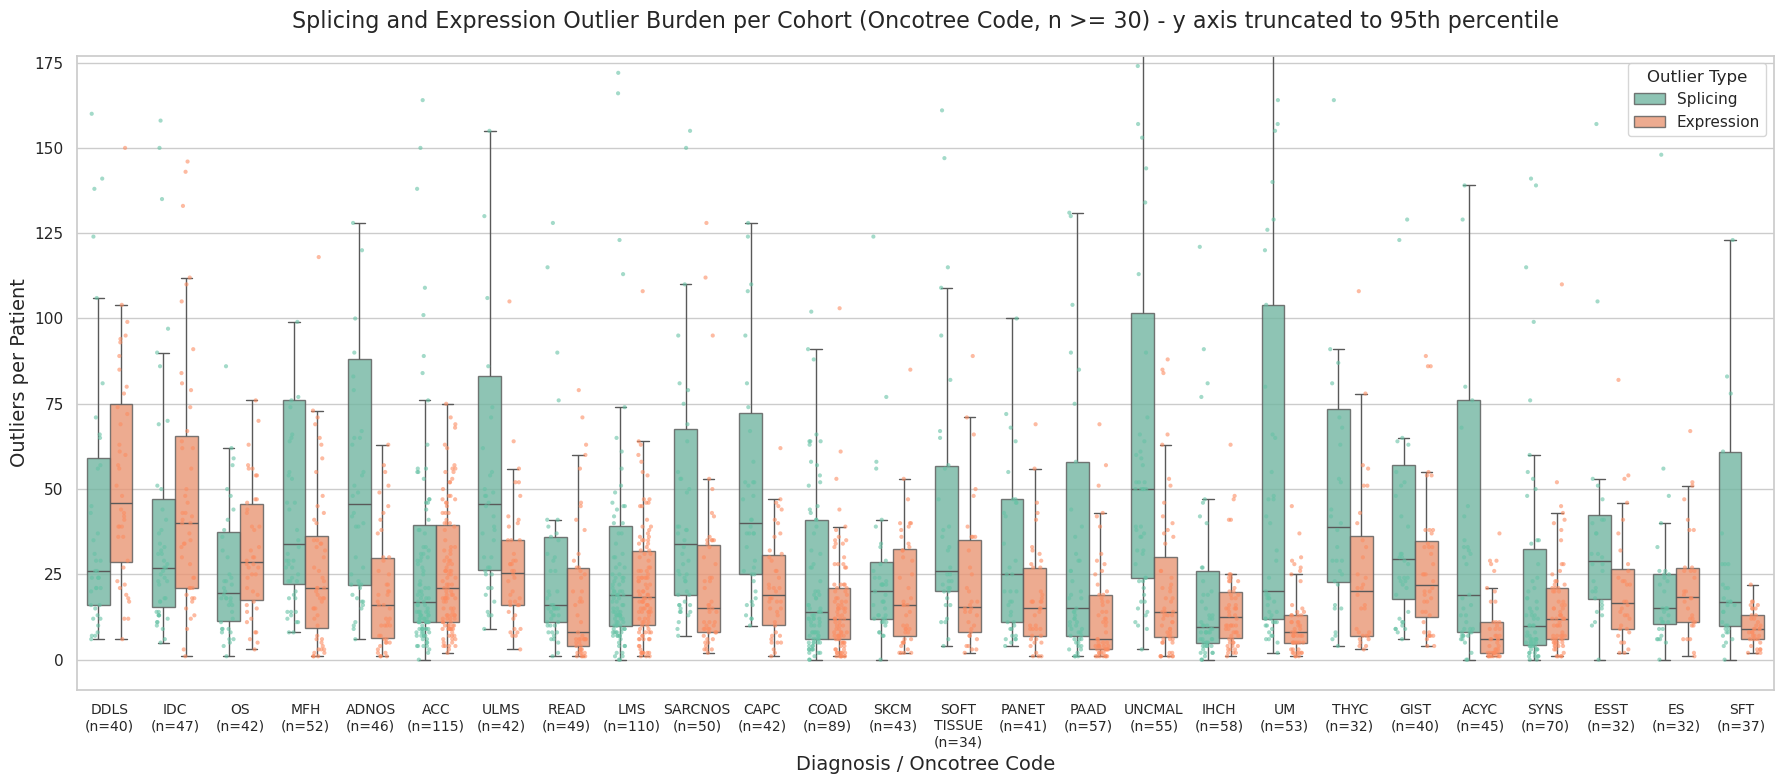

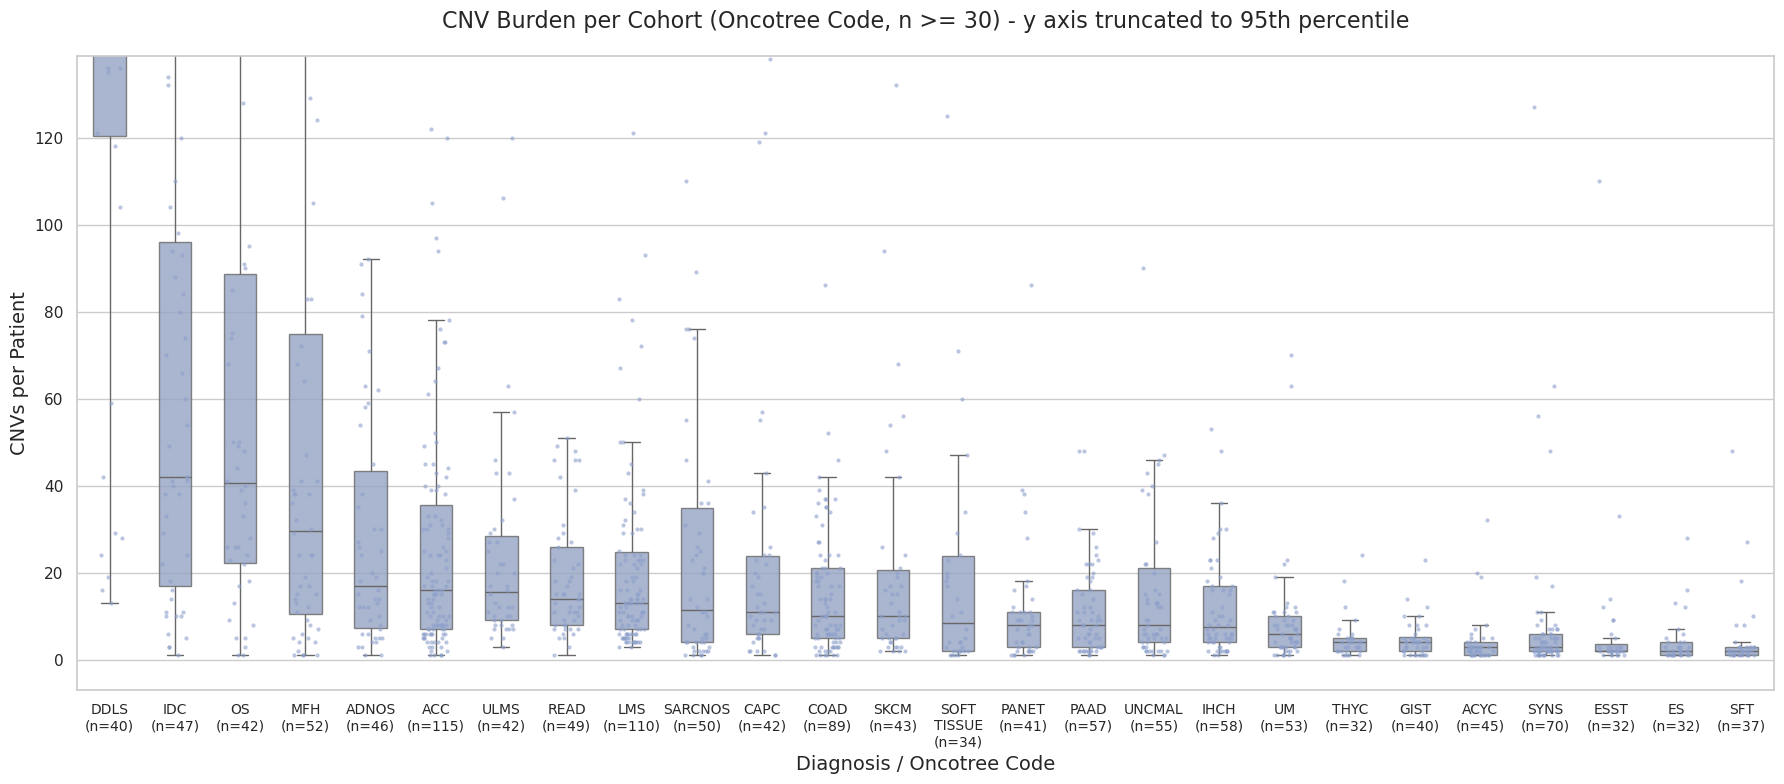

In [13]:
DIAG_COL = 'Oncotree Code'
SAMPLE_ID = 'random_id'
MIN_SAMPLES = 30

unique_segments = res.drop_duplicates(subset=[SAMPLE_ID, 'seqnames', 'start', 'end'])
cnv_burden = unique_segments.groupby(SAMPLE_ID).size().reset_index(name='CNV')
splicing_burden = splicing.groupby(SAMPLE_ID).size().reset_index(name='Splicing')
expression_burden = outrider.groupby(SAMPLE_ID).size().reset_index(name='Expression')

analysis_df = res[[SAMPLE_ID, DIAG_COL]].drop_duplicates().copy()
for df in [cnv_burden, splicing_burden, expression_burden]:
    analysis_df = pd.merge(analysis_df, df, on=SAMPLE_ID, how='left')

analysis_df.fillna(0, inplace=True)

analysis_df = analysis_df[(analysis_df[DIAG_COL] != 0) & (analysis_df[DIAG_COL] != '0')]
analysis_df[DIAG_COL] = analysis_df[DIAG_COL].replace({'SOFT_TISSUE': 'SOFT\nTISSUE'})

diag_counts = analysis_df[DIAG_COL].value_counts()
valid_diags = diag_counts[diag_counts >= MIN_SAMPLES].index.tolist()
plot_df = analysis_df[analysis_df[DIAG_COL].isin(valid_diags)].copy()

median_order = plot_df.groupby(DIAG_COL)['CNV'].median().sort_values(ascending=False).index
plot_df[DIAG_COL] = pd.Categorical(plot_df[DIAG_COL], categories=median_order, ordered=True)
plot_df = plot_df.sort_values(DIAG_COL)

labels = [f"{diag}\n(n={diag_counts[diag]})" for diag in median_order]

melt_vars_1 = ['Splicing', 'Expression']
melted_df_1 = plot_df.melt(id_vars=[SAMPLE_ID, DIAG_COL], value_vars=melt_vars_1, var_name='Outlier Type', value_name='Burden')
y_max_1 = melted_df_1['Burden'].quantile(0.95)

plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=melted_df_1, x=DIAG_COL, y='Burden', hue='Outlier Type',
    palette='Set2', width=0.7, showfliers=False, boxprops={'alpha': 0.8}
)
sns.stripplot(
    data=melted_df_1, x=DIAG_COL, y='Burden', hue='Outlier Type',
    dodge=True, palette='Set2', jitter=0.2, size=3, alpha=0.6, legend=False
)

plt.xticks(ticks=range(len(median_order)), labels=labels, fontsize=10, ha='center')
plt.ylim(bottom=-max(1, y_max_1 * 0.05), top=y_max_1)
plt.title(f'Splicing and Expression Outlier Burden per Cohort ({DIAG_COL}, n >= {MIN_SAMPLES}) - y axis truncated to 95th percentile', fontsize=16, pad=20)
plt.ylabel('Outliers per Patient', fontsize=14)
plt.xlabel('Diagnosis / Oncotree Code', fontsize=14)
plt.tight_layout()
plt.show()

y_max_2 = plot_df['CNV'].quantile(0.95)

plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")
set2_colors = sns.color_palette("Set2")

sns.boxplot(
    data=plot_df, x=DIAG_COL, y='CNV',
    color=set2_colors[2], width=0.5, showfliers=False, boxprops={'alpha': 0.8}
)
sns.stripplot(
    data=plot_df, x=DIAG_COL, y='CNV',
    color=set2_colors[2], jitter=0.2, size=3, alpha=0.6
)

plt.xticks(ticks=range(len(median_order)), labels=labels, fontsize=10, ha='center')
plt.ylim(bottom=-max(1, y_max_2 * 0.05), top=y_max_2)
plt.title(f'CNV Burden per Cohort ({DIAG_COL}, n >= {MIN_SAMPLES}) - y axis truncated to 95th percentile', fontsize=16, pad=20)
plt.ylabel('CNVs per Patient', fontsize=14)
plt.xlabel('Diagnosis / Oncotree Code', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
import plotly.graph_objects as go

code_counts = cohort_df['Oncotree Code'].value_counts().reset_index()
code_counts.columns = ['Oncotree Code', 'Count']

TOP_N = 30
top_codes = code_counts.nlargest(TOP_N, 'Count')['Oncotree Code'].tolist()

major_df = code_counts[code_counts['Oncotree Code'].isin(top_codes)].copy()
minor_df = code_counts[~code_counts['Oncotree Code'].isin(top_codes)].copy()

major_df = major_df.sort_values('Count', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=major_df['Count'],
    y=major_df['Oncotree Code'],
    orientation='h',
    marker=dict(color='#595959'), 
    showlegend=False,
    name='Major Codes'
))

minor_df = minor_df.sort_values('Count', ascending=False)
color_palette = px.colors.qualitative.Pastel 

for i, (index, row) in enumerate(minor_df.iterrows()):
    fig.add_trace(go.Bar(
        x=[row['Count']],
        y=['Remaining sample'],
        orientation='h',
        name=row['Oncotree Code'],
        marker=dict(color=color_palette[i % len(color_palette)])
    ))

y_axis_order = major_df['Oncotree Code'].tolist() + ['Remaining sample']

fig.update_layout(
    barmode='stack',
    template='plotly_white', 
    yaxis=dict(
        categoryorder='array',
        categoryarray=y_axis_order,
        title='',
        tickfont=dict(size=12)
    ),
    xaxis=dict(
        title='Count',
        tickfont=dict(size=12),
        showgrid=True,
        gridcolor='lightgrey'
    ),
    legend=dict(
        title='Oncotree Code',
        title_font=dict(size=14),
        font=dict(size=11),
        traceorder='normal'
    ),
    margin=dict(l=10, r=10, t=20, b=20)
)

fig.show()

In [16]:
lineage_counts = cohort_lineage_df['Lineage'].value_counts().reset_index()
lineage_counts.columns = ['Lineage', 'Count']

TOP_N = 15

valid_lineages = lineage_counts[lineage_counts['Lineage'] != 'Other']
top_lineages = valid_lineages.nlargest(TOP_N, 'Count')['Lineage'].tolist()

major_df = lineage_counts[lineage_counts['Lineage'].isin(top_lineages)].copy()
minor_df = lineage_counts[~lineage_counts['Lineage'].isin(top_lineages)].copy()

major_df = major_df.sort_values('Count', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=major_df['Count'],
    y=major_df['Lineage'],
    orientation='h',
    marker=dict(color='#595959'), 
    showlegend=False,
    name='Major Lineages'
))

minor_df = minor_df.sort_values('Count', ascending=False)
color_palette = px.colors.qualitative.Pastel

for i, (index, row) in enumerate(minor_df.iterrows()):
    fig.add_trace(go.Bar(
        x=[row['Count']],
        y=['Remaining sample'],
        orientation='h',
        name=row['Lineage'],
        marker=dict(color=color_palette[i % len(color_palette)])
    ))

y_axis_order = major_df['Lineage'].tolist() + ['Remaining sample']

fig.update_layout(
    barmode='stack',
    template='plotly_white', 
    yaxis=dict(
        categoryorder='array',
        categoryarray=y_axis_order,
        title='',
        tickfont=dict(size=12)
    ),
    xaxis=dict(
        title='Count',
        tickfont=dict(size=12),
        showgrid=True,
        gridcolor='lightgrey'
    ),
    legend=dict(
        title='Tissue of origin',
        title_font=dict(size=14),
        font=dict(size=11),
        traceorder='normal'
    ),
    margin=dict(l=10, r=10, t=20, b=20)
)

fig.show()

Recreation of heatmap (Fig. 2c) from [Huang KL, Mashl RJ, Wu Y, et al.](https://pmc.ncbi.nlm.nih.gov/articles/PMC5949147/)

In [30]:
cancers = ['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'DLBC', 'ESCA', 'GBM', 'HNSC', 'KICH', 'KIRC', 
            'KIRP', 'LAML', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'MESO', 'OV', 'PAAD', 'PCPG', 'PRAD', 'READ', 'SARC',
            'SKCM', 'STAD', 'TGCT', 'THCA', 'THYM', 'UCEC', 'UCS', 'UVM']
            
path_genes = [
    'BRCA1', 'BRCA2', 'ATM', 'PALB2', 'RET', 'NF1', 'MSH6', 'TP53',
    'VHL', 'BUB1B', 'SDHA', 'BAP1', 'SDHB', 'MAX', 'APC', 'FH',
    'WRN', 'SDHD', 'MET', 'HFE', 'PTEN'
]
# no samples in germline data for following genes: RET, MSH6, SDHB, MAX, APC, FH, WRN, HFE, PTEN

In [26]:
tcga_map = {
    # breast
    'IDC': 'BRCA', 'ILC': 'BRCA', 'MDLC': 'BRCA', 'BRCA': 'BRCA', 'BREAST': 'BRCA',
    
    # kidney
    'CCRCC': 'KIRC', 'PRCC': 'KIRP', 'CHRB': 'KICH', 'KIRC': 'KIRC', 'KIRP': 'KIRP', 'KICH': 'KICH',
    
    # sarcoma
    'OS': 'SARC', 'LMS': 'SARC', 'ANGS': 'SARC', 'CHS': 'SARC', 'MPNST': 'SARC', 
    'SOFT_TISSUE': 'SARC', 'SCSARC': 'SARC', 'UPS': 'SARC', 'MFS': 'SARC', 'SARC': 'SARC',
    
    # gastrointestinal
    'ADNOS': 'COAD', 'COAD': 'COAD', 'READ': 'READ', 'STAD': 'STAD', 'SDCA': 'STAD',
    'PAAD': 'PAAD', 'PANET': 'PAAD', 'LIHC': 'LIHC', 'LIVER': 'LIHC', 'CHOL': 'CHOL', 
    'ESCA': 'ESCA', 'EAC': 'ESCA', 'ESCC': 'ESCA',
    
    # lung
    'LUAD': 'LUAD', 'LUSC': 'LUSC', 'NSCLC': 'LUAD',
    
    # brain
    'GBM': 'GBM', 'LGG': 'LGG', 'AA': 'LGG', 'ODG': 'LGG', 'ASTR': 'LGG',
    
    # other
    'THYM': 'THYM', 'UM': 'UVM', 'UVM': 'UVM', 'SKCM': 'SKCM', 'MEL': 'SKCM',
    'OV': 'OV', 'HNSC': 'HNSC', 'PRAD': 'PRAD', 'UCEC': 'UCEC', 'UCS': 'UCS',
    'BLCA': 'BLCA', 'ACC': 'ACC', 'CESC': 'CESC', 'DLBC': 'DLBC', 'MESO': 'MESO',
    'PCPG': 'PCPG', 'TGCT': 'TGCT', 'NSGCT': 'TGCT', 'SEM': 'TGCT', 'THCA': 'THCA',
    'THAP': 'THCA', 'LAML': 'LAML', 'AML': 'LAML'
}

In [27]:
gene_map = {g.split(' [')[0]: g for g in path_genes}
clean_genes = list(gene_map.keys())

res['TCGA_Code'] = res['Oncotree Code'].map(tcga_map)
res['TCGA_Code'] = res['TCGA_Code'].fillna(res['Oncotree Code'])

In [31]:
cohort_sizes = res.drop_duplicates(SAMPLE_ID).groupby('TCGA_Code').size()
hits = res[res['Gene'].isin(clean_genes)]
carrier_matrix = hits.groupby(['Gene', 'TCGA_Code'])[SAMPLE_ID].nunique().unstack(fill_value=0)

relevant_sizes = cohort_sizes.reindex(carrier_matrix.columns)
carrier_pct_matrix = carrier_matrix.divide(cohort_sizes.reindex(carrier_matrix.columns), axis=1) * 100
carrier_pct_matrix.index = [gene_map.get(g, g) for g in carrier_pct_matrix.index]
final_heatmap_df = carrier_pct_matrix.reindex(index=path_genes, columns=cancers).fillna(0)

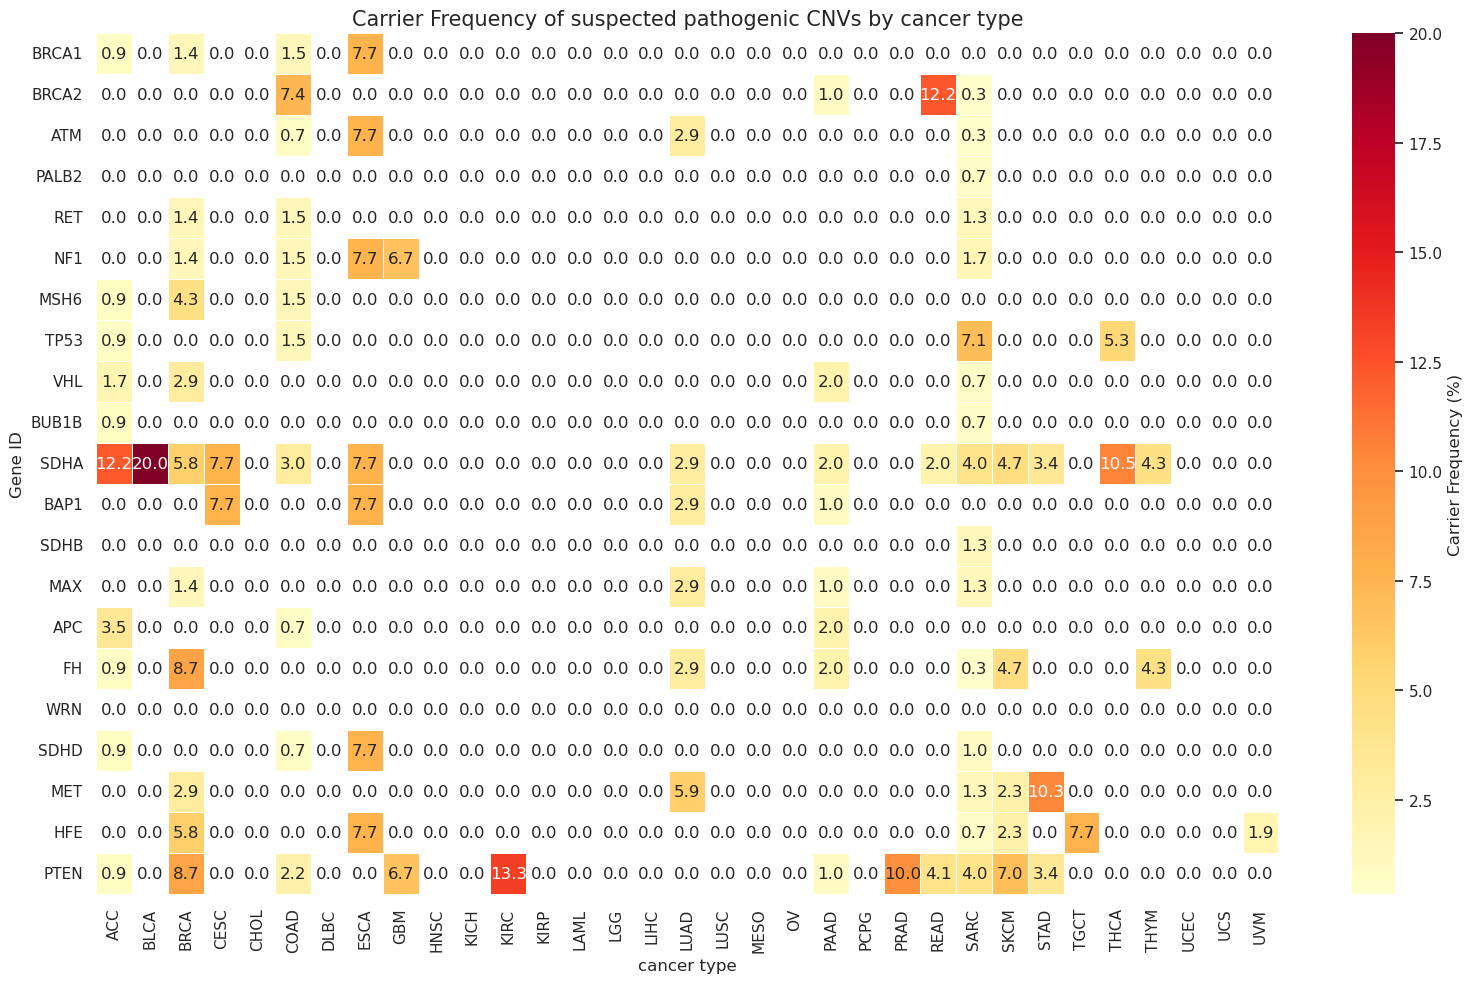

In [32]:
plt.figure(figsize=(16,10))
cmap = sns.color_palette('YlOrRd', as_cmap=True)
cmap.set_under('white')
mask_pos = final_heatmap_df > 0

ax = sns.heatmap(final_heatmap_df, 
                 annot=True,
                 fmt=".1f",  
                 cmap=cmap,
                 vmin= final_heatmap_df[mask_pos].min().min(),
                 linewidths=.5,
                 cbar_kws={'label': 'Carrier Frequency (%)'})

plt.title('Carrier Frequency of suspected pathogenic CNVs by cancer type', fontsize=15)
plt.xlabel('cancer type')
plt.ylabel('Gene ID')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()